# NMNIST: BP vs FF Accuracy vs T

比较同一种 neuron（`lif`, `alif`, `srm`, `dynsrm`）在 BP 与 FF 训练下，随着时间步 `T`（2, 4, 8, 10, 16）变化时的 accuracy 曲线。

- BP 结果目录：`SNNFF/BP/NMNIST/v2/result/timestep/`
- FF 结果目录：`SNNFF/FF/NMNIST/v2/result/timestep/`

默认行为：每个 `(method, model, T)` 会读取对应目录下的结果 CSV，并用 `best_test_acc` 的最大值作为该点。

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

NEURONS = ["lif", "alif", "srm", "dynsrm"]
TS = [2, 4, 8, 10, 16]

BP_ROOT = Path("/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/NMNIST/v2/result/timestep")
FF_ROOT = Path("/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/NMNIST/v2/result/timestep")
OUT_DIR = BP_ROOT / "plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def method_csv_path(method: str, model: str, t: int) -> Path:
    if method == "BP":
        return BP_ROOT / model / f"T{t}" / f"NMNIST_BP_{model}_results.csv"
    return FF_ROOT / model / f"T{t}" / f"NMNIST_{model}_FF_compare.csv"


def best_acc_from_csv(path: Path) -> float:
    if not path.exists():
        return np.nan
    df = pd.read_csv(path)
    if df.empty:
        return np.nan
    if "best_test_acc" in df.columns:
        return float(pd.to_numeric(df["best_test_acc"], errors="coerce").max())
    if "test_acc" in df.columns:
        return float(pd.to_numeric(df["test_acc"], errors="coerce").max())
    return np.nan


rows = []
for model in NEURONS:
    for t in TS:
        for method in ["BP", "FF"]:
            csv_path = method_csv_path(method, model, t)
            acc = best_acc_from_csv(csv_path)
            rows.append({
                "method": method,
                "model": model,
                "T": t,
                "best_test_acc": acc,
                "csv_path": str(csv_path),
                "exists": csv_path.exists(),
            })

result_df = pd.DataFrame(rows).sort_values(["model", "method", "T"]).reset_index(drop=True)
print("Collected rows:", len(result_df))
display(result_df)


Collected rows: 40


,method,model,T,best_test_acc,csv_path,exists
0,BP,alif,2,0.9109,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
1,BP,alif,4,0.9649,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
2,BP,alif,8,0.9727,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
3,BP,alif,10,0.9729,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
4,BP,alif,16,0.9741,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
5,FF,alif,2,0.9645,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
6,FF,alif,4,0.9659,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
7,FF,alif,8,0.9659,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
8,FF,alif,10,0.9677,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
9,FF,alif,16,NaN,/home/yhxu/spikingjelly/spikingjelly/spikingje...,False


Saved figure: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/NMNIST/v2/result/timestep/plots/bp_ff_accuracy_vs_timestep_nmnist.png


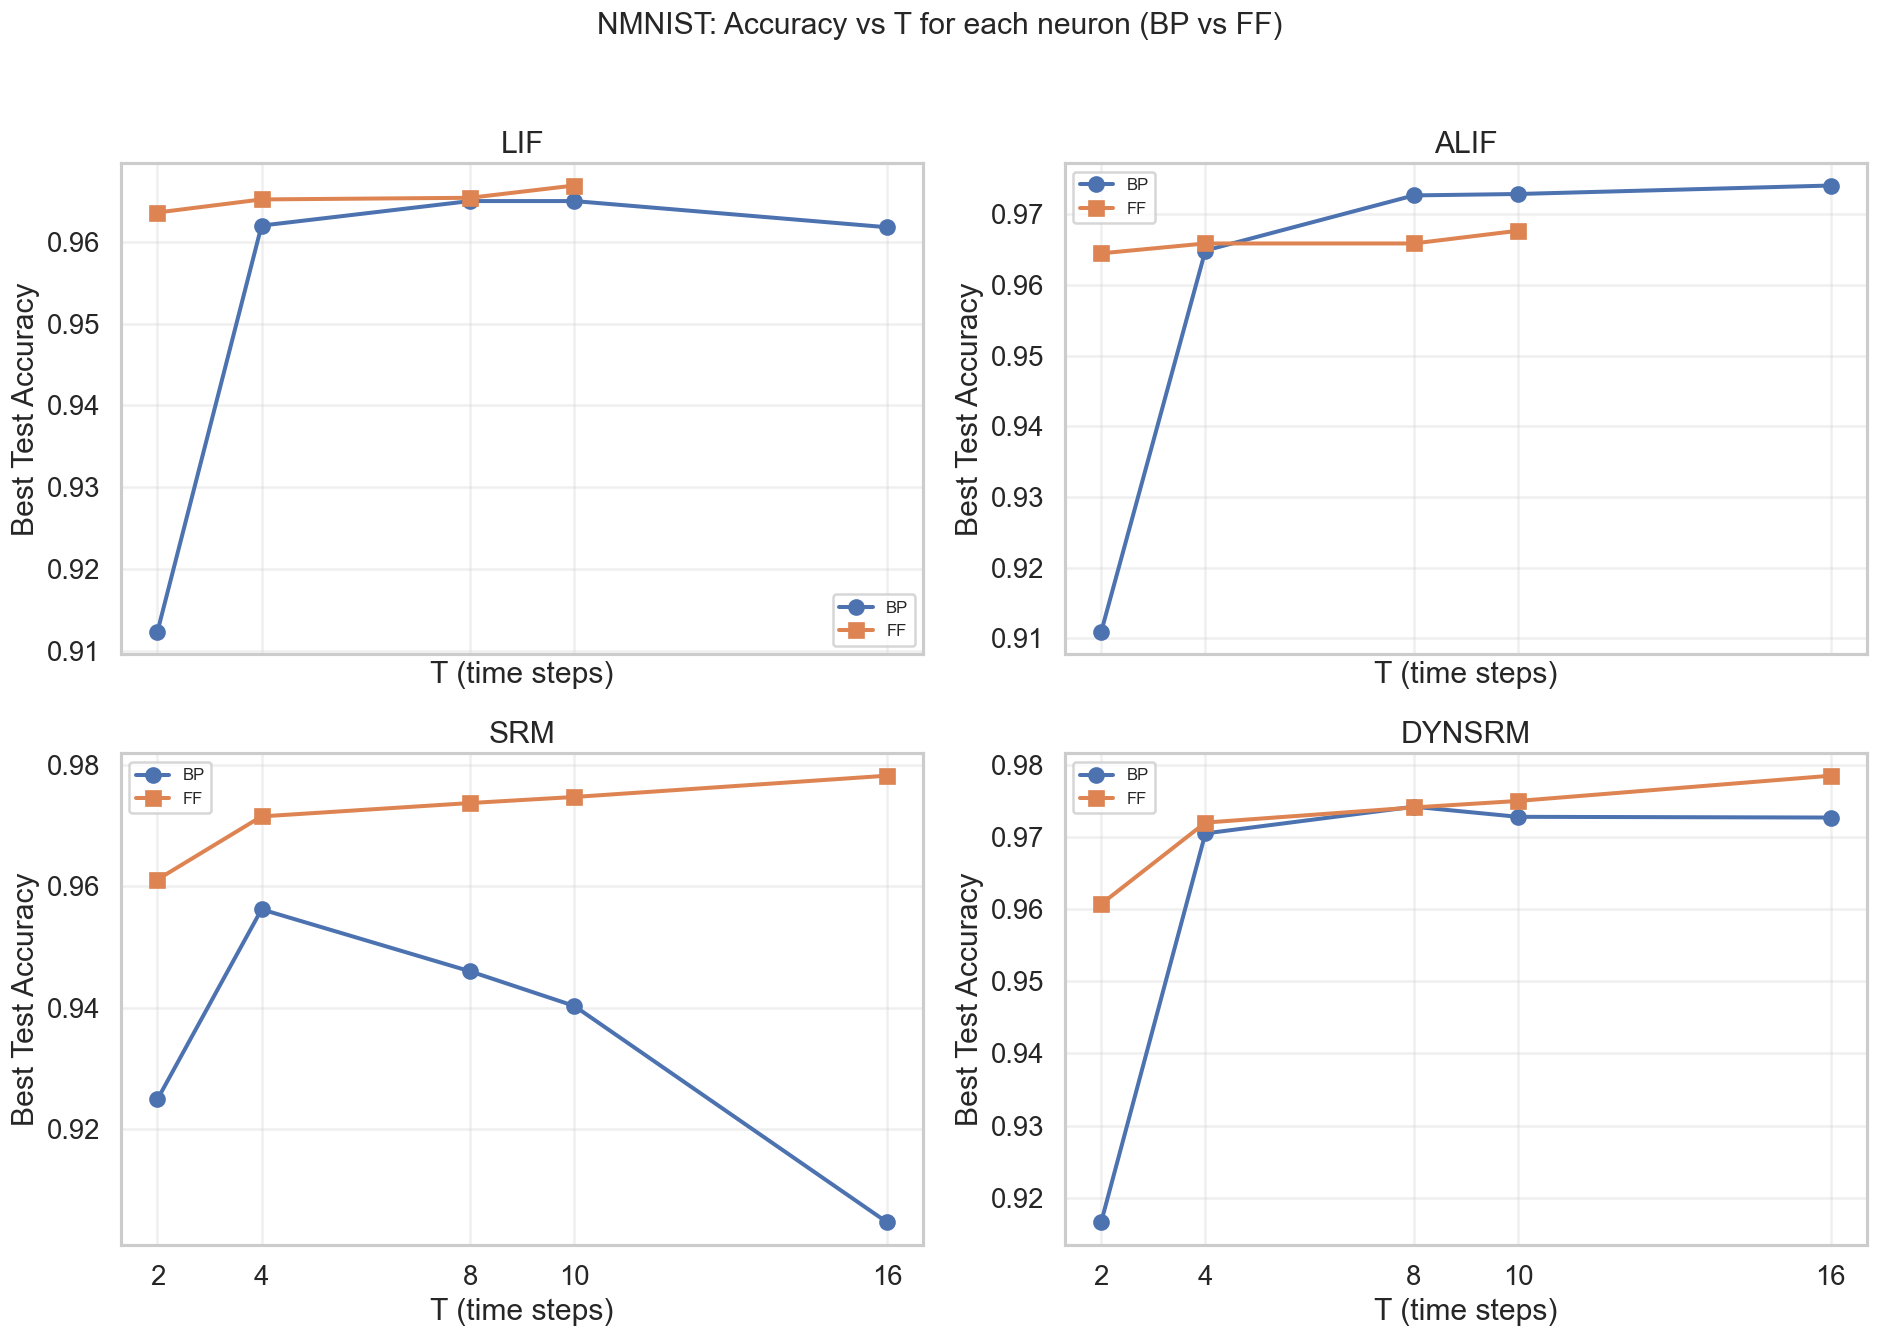


Pivot table (best_test_acc):


method,model,T,BP,FF
0,alif,2,0.9109,0.9645
1,alif,4,0.9649,0.9659
2,alif,8,0.9727,0.9659
3,alif,10,0.9729,0.9677
4,alif,16,0.9741,NaN
5,dynsrm,2,0.9166,0.9607
6,dynsrm,4,0.9705,0.9720
7,dynsrm,8,0.9742,0.9741
8,dynsrm,10,0.9728,0.9750
9,dynsrm,16,0.9727,0.9785


Saved table: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/NMNIST/v2/result/timestep/plots/bp_ff_accuracy_vs_timestep_nmnist_table.csv


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True, sharey=False)
axes = axes.ravel()

for i, model in enumerate(NEURONS):
    ax = axes[i]
    sub = result_df[result_df["model"] == model].copy()

    bp = sub[sub["method"] == "BP"].sort_values("T")
    ff = sub[sub["method"] == "FF"].sort_values("T")

    ax.plot(bp["T"], bp["best_test_acc"], marker="o", linewidth=2.4, label="BP")
    ax.plot(ff["T"], ff["best_test_acc"], marker="s", linewidth=2.4, label="FF")

    ax.set_title(model.upper())
    ax.set_xlabel("T (time steps)")
    ax.set_ylabel("Best Test Accuracy")
    ax.set_xticks(TS)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=10)

fig.suptitle("NMNIST: Accuracy vs T for each neuron (BP vs FF)", fontsize=18, y=1.02)
fig.tight_layout()

fig_path = OUT_DIR / "bp_ff_accuracy_vs_timestep_nmnist.png"
fig.savefig(fig_path, bbox_inches="tight")
print(f"Saved figure: {fig_path}")
plt.show()

pivot_df = result_df.pivot_table(index=["model", "T"], columns="method", values="best_test_acc", aggfunc="max").reset_index()
print("\nPivot table (best_test_acc):")
display(pivot_df)

csv_path = OUT_DIR / "bp_ff_accuracy_vs_timestep_nmnist_table.csv"
pivot_df.to_csv(csv_path, index=False)
print(f"Saved table: {csv_path}")


Saved: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/NMNIST/v2/result/timestep/plots/bp_ff_nmnist_loss_vs_epoch_dual_axis_T10.png


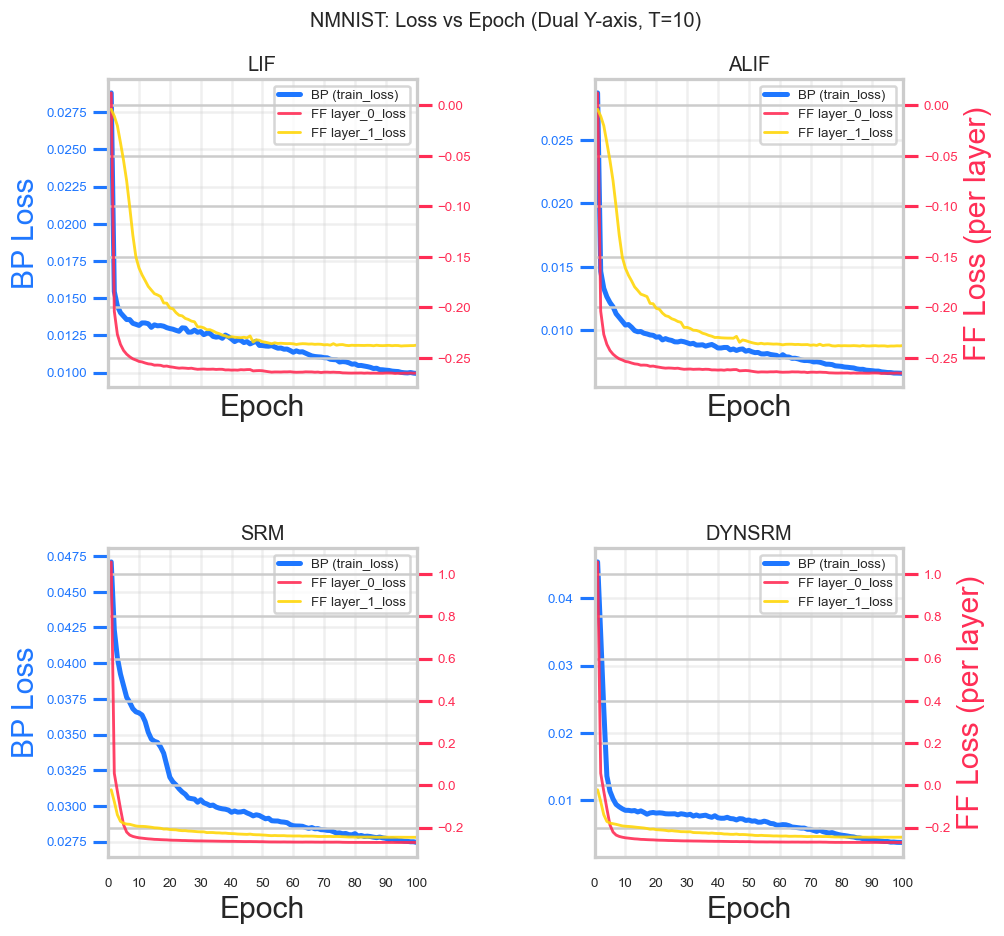

In [12]:
# NMNIST loss-vs-epoch comparison: BP vs FF (dual y-axis), mimicking MNIST style
import re

# Select which timestep run to compare
PLOT_T = 10
X_MAX = 100

if "NEURONS" not in globals():
    NEURONS = ["lif", "alif", "srm", "dynsrm"]
if "method_csv_path" not in globals():
    def method_csv_path(method: str, model: str, t: int) -> Path:
        if method == "BP":
            return BP_ROOT / model / f"T{t}" / f"NMNIST_BP_{model}_results.csv"
        return FF_ROOT / model / f"T{t}" / f"NMNIST_{model}_FF_compare.csv"


def _ff_layer_loss_cols(df: pd.DataFrame):
    cols = [c for c in df.columns if re.match(r"^layer_\d+_loss$", c)]
    return sorted(cols, key=lambda x: int(re.findall(r"\d+", x)[0]))


def _clean_alif_epoch_only(epoch_like, y_like):
    """Only for ALIF: merge duplicated epochs to remove abnormal straight-line connections."""
    ep = pd.to_numeric(pd.Series(epoch_like), errors="coerce")
    yy = pd.to_numeric(pd.Series(y_like), errors="coerce")
    tmp = pd.DataFrame({"epoch": ep, "y": yy}).dropna(subset=["epoch", "y"])
    if tmp.empty:
        return np.array([]), np.array([])
    tmp = tmp.groupby("epoch", as_index=False)["y"].median().sort_values("epoch")
    return tmp["epoch"].to_numpy(), tmp["y"].to_numpy()


def _bp_loss_series(df: pd.DataFrame):
    for c in ["train_loss", "loss", "total_loss", "test_loss"]:
        if c in df.columns:
            s = pd.to_numeric(df[c], errors="coerce")
            if np.isfinite(s).any() and not np.allclose(s.fillna(0).values, 0.0):
                return s, c

    layer_cols = _ff_layer_loss_cols(df)
    if layer_cols:
        s = df[layer_cols].apply(pd.to_numeric, errors="coerce").sum(axis=1)
        if np.isfinite(s).any() and not np.allclose(s.fillna(0).values, 0.0):
            return s, " + ".join(layer_cols)

    if "train_acc" in df.columns:
        return (1.0 - pd.to_numeric(df["train_acc"], errors="coerce")), "BP_loss"

    return pd.Series(dtype=float), "missing"


fig, axes = plt.subplots(2, 2, figsize=(8.0, 8.0), sharex=True, sharey=False)
axes = axes.ravel()

x_ticks = np.arange(0, X_MAX + 1, 10)

for i, model in enumerate(NEURONS):
    ax_bp = axes[i]
    ax_ff = ax_bp.twinx()

    bp_csv = method_csv_path("BP", model, PLOT_T)
    ff_csv = method_csv_path("FF", model, PLOT_T)

    bp_df = pd.read_csv(bp_csv) if bp_csv.exists() else pd.DataFrame()
    ff_df = pd.read_csv(ff_csv) if ff_csv.exists() else pd.DataFrame()

    # Epoch axis fallback
    bp_epoch = bp_df["epoch"].to_numpy() if (not bp_df.empty and "epoch" in bp_df.columns) else np.arange(1, len(bp_df) + 1)
    ff_epoch = ff_df["epoch"].to_numpy() if (not ff_df.empty and "epoch" in ff_df.columns) else np.arange(1, len(ff_df) + 1)

    # BP curve (keep original behavior)
    bp_loss, bp_loss_label = _bp_loss_series(bp_df)
    bp_line = None
    if len(bp_loss) > 0:
        bp_mask = bp_epoch <= X_MAX
        bp_line, = ax_bp.plot(bp_epoch[bp_mask], bp_loss.to_numpy()[bp_mask], lw=3.0, color="#1f77ff",
                              label=f"BP ({bp_loss_label})", zorder=4)

    # FF layer curves
    ff_lines = []
    if not ff_df.empty:
        ff_cols = _ff_layer_loss_cols(ff_df)
        if ff_cols:
            ff_palette = ["#ff2d55", "#ffd60a"]
            if len(ff_cols) <= len(ff_palette):
                ff_colors = ff_palette[:len(ff_cols)]
            else:
                ff_colors = ff_palette + list(plt.cm.plasma(np.linspace(0.35, 0.95, len(ff_cols) - len(ff_palette))))
            for j, col in enumerate(ff_cols):
                y = pd.to_numeric(ff_df[col], errors="coerce").to_numpy()

                # Only ALIF gets duplicate-epoch cleanup.
                if model == "alif":
                    x_plot, y_plot = _clean_alif_epoch_only(ff_epoch, y)
                else:
                    x_plot, y_plot = ff_epoch, y

                mask = x_plot <= X_MAX
                line, = ax_ff.plot(x_plot[mask], y_plot[mask], lw=1.7, alpha=0.9, color=ff_colors[j],
                                   label=f"FF {col}", zorder=2)
                ff_lines.append(line)
        else:
            for c in ["train_loss", "loss", "total_loss"]:
                if c in ff_df.columns:
                    y = pd.to_numeric(ff_df[c], errors="coerce").to_numpy()
                    if model == "alif":
                        x_plot, y_plot = _clean_alif_epoch_only(ff_epoch, y)
                    else:
                        x_plot, y_plot = ff_epoch, y
                    mask = x_plot <= X_MAX
                    line, = ax_ff.plot(x_plot[mask], y_plot[mask], lw=1.7, alpha=0.9, color="#ff2d55",
                                       label=f"FF {c}", zorder=2)
                    ff_lines.append(line)
                    break

    ax_bp.set_title(model.upper(), fontsize=12, pad=5)
    ax_bp.set_xlabel("Epoch")
    ax_bp.set_xlim(0, X_MAX)
    ax_bp.set_xticks(x_ticks)

    if i % 2 == 0:
        ax_bp.set_ylabel("BP Loss", color="#1f77ff")
    else:
        ax_bp.set_ylabel("")
    if i % 2 == 1:
        ax_ff.set_ylabel("FF Loss (per layer)", color="#ff2d55")
    else:
        ax_ff.set_ylabel("")

    ax_bp.tick_params(axis="y", colors="#1f77ff", labelsize=8)
    ax_ff.tick_params(axis="y", colors="#ff2d55", labelsize=8)
    ax_bp.tick_params(axis="x", labelsize=8)
    ax_bp.grid(True, alpha=0.3)
    ax_bp.set_box_aspect(1)

    handles = ([] if bp_line is None else [bp_line]) + ff_lines
    if handles:
        labels = [h.get_label() for h in handles]
        ax_bp.legend(handles, labels, fontsize=8, frameon=True, loc="best", borderpad=0.3, handlelength=1.7)
    else:
        ax_bp.text(0.5, 0.5, f"No loss data\n(T={PLOT_T})", transform=ax_bp.transAxes,
                   ha="center", va="center", fontsize=9)

fig.suptitle(f"NMNIST: Loss vs Epoch (Dual Y-axis, T={PLOT_T})", fontsize=12, y=0.97)
fig.tight_layout(pad=0.45)
fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.09, wspace=0.52, hspace=0.52)

loss_path = OUT_DIR / f"bp_ff_nmnist_loss_vs_epoch_dual_axis_T{PLOT_T}.png"
fig.savefig(loss_path, bbox_inches="tight")
print(f"Saved: {loss_path}")
plt.show()


Event/Dense ratio rows: 40


,method,model,T,event_dense_ratio,ratio_col,csv_path,exists
0,BP,alif,2,0.209010,mean_event_to_dense_ratio,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
1,BP,alif,4,0.143744,mean_event_to_dense_ratio,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
2,BP,alif,8,0.095623,mean_event_to_dense_ratio,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
3,BP,alif,10,0.080967,mean_event_to_dense_ratio,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
4,BP,alif,16,0.060602,mean_event_to_dense_ratio,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
5,FF,alif,2,0.361783,mean_event_to_dense_ratio,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
6,FF,alif,4,0.258743,mean_event_to_dense_ratio,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
7,FF,alif,8,0.171271,mean_event_to_dense_ratio,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
8,FF,alif,10,0.151299,mean_event_to_dense_ratio,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
9,FF,alif,16,NaN,,/home/yhxu/spikingjelly/spikingjelly/spikingje...,False


Saved figure: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/NMNIST/v2/result/timestep/plots/bp_ff_event_dense_ratio_vs_timestep_nmnist.png


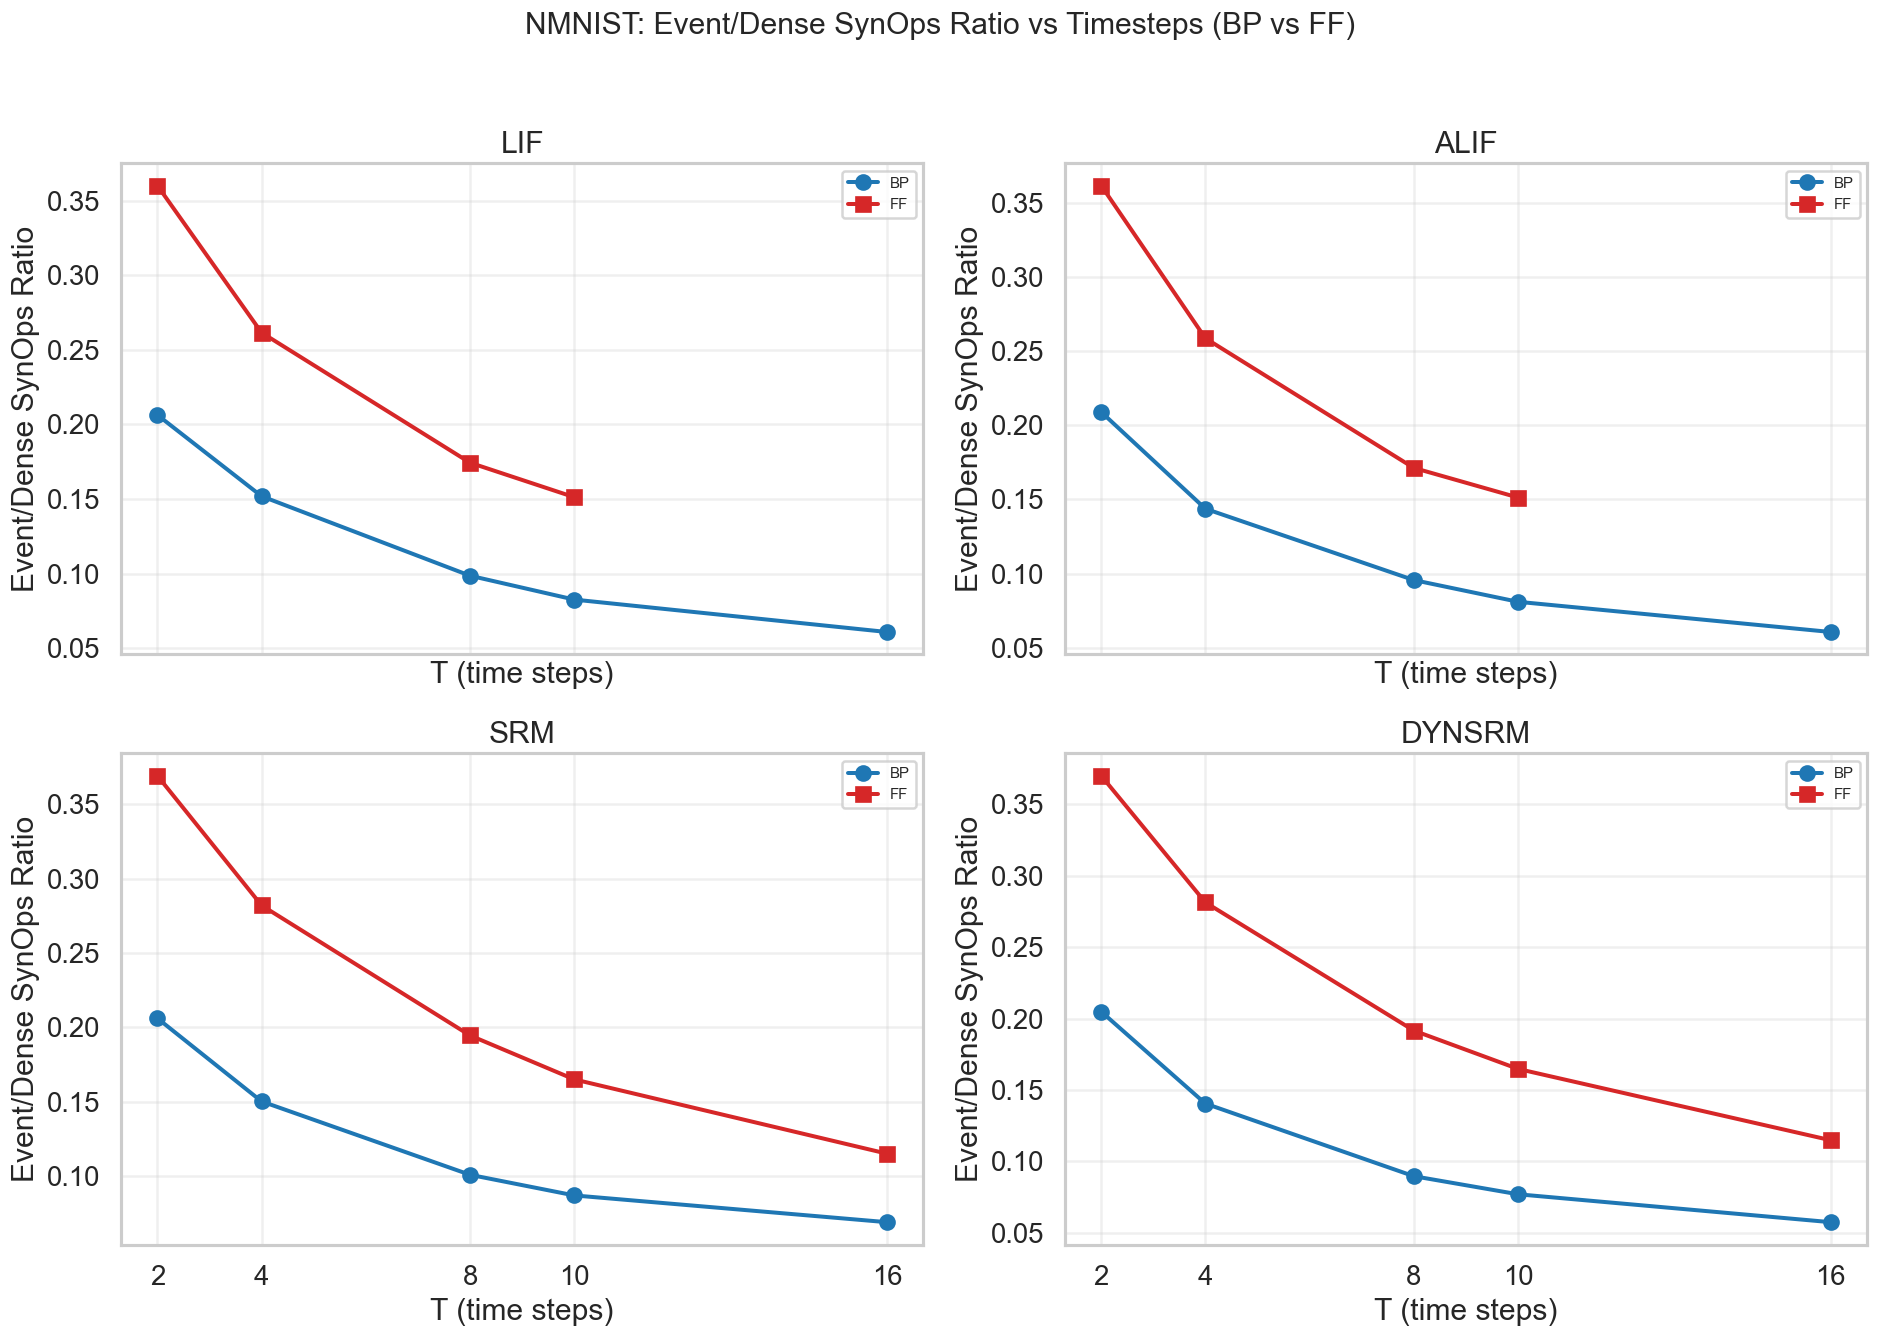

Saved table: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/NMNIST/v2/result/timestep/plots/bp_ff_event_dense_ratio_vs_timestep_nmnist_table.csv


In [11]:
# Event/Dense SynOps ratio vs Timesteps (BP vs FF) for NMNIST

ratio_col_candidates = [
    "test_event_to_dense_ratio",      # if available
    "mean_event_to_dense_ratio",      # NMNIST scripts usually use this
    "final_test_event_ratio",         # fallback naming
]


def read_ratio_from_csv(csv_path: Path):
    try:
        df = pd.read_csv(csv_path)
    except Exception:
        return np.nan, None
    if df.empty:
        return np.nan, None

    score_col = "best_test_acc" if "best_test_acc" in df.columns else ("test_acc" if "test_acc" in df.columns else None)
    if score_col is None:
        row = df.iloc[-1]
    else:
        score = pd.to_numeric(df[score_col], errors="coerce")
        row = df.iloc[int(score.fillna(-np.inf).idxmax())]

    for c in ratio_col_candidates:
        if c in df.columns:
            v = pd.to_numeric(pd.Series([row[c]]), errors="coerce").iloc[0]
            return (float(v) if pd.notna(v) else np.nan), c
    return np.nan, None


ratio_records = []
for model in NEURONS:
    for t in TS:
        for method in ["BP", "FF"]:
            csv_path = method_csv_path(method, model, t)
            ratio, used_col = read_ratio_from_csv(csv_path)
            ratio_records.append({
                "method": method,
                "model": model,
                "T": t,
                "event_dense_ratio": ratio,
                "ratio_col": "" if used_col is None else used_col,
                "csv_path": str(csv_path),
                "exists": csv_path.exists(),
            })

ratio_df = pd.DataFrame(ratio_records).sort_values(["model", "method", "T"]).reset_index(drop=True)
print("Event/Dense ratio rows:", len(ratio_df))
display(ratio_df)

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True, sharey=False)
axes = axes.ravel()
color_map = {"BP": "#1f77b4", "FF": "#d62728"}
marker_map = {"BP": "o", "FF": "s"}

for i, model in enumerate(NEURONS):
    ax = axes[i]
    sub = ratio_df[ratio_df["model"] == model]

    for method in ["BP", "FF"]:
        d = sub[sub["method"] == method].sort_values("T")
        ax.plot(
            d["T"],
            d["event_dense_ratio"],
            marker=marker_map[method],
            linewidth=2.4,
            color=color_map[method],
            label=method,
        )

    ax.set_title(model.upper())
    ax.set_xlabel("T (time steps)")
    ax.set_ylabel("Event/Dense SynOps Ratio")
    ax.set_xticks(TS)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=9)

fig.suptitle("NMNIST: Event/Dense SynOps Ratio vs Timesteps (BP vs FF)", fontsize=18, y=1.02)
fig.tight_layout()

ratio_fig_path = OUT_DIR / "bp_ff_event_dense_ratio_vs_timestep_nmnist.png"
fig.savefig(ratio_fig_path, bbox_inches="tight")
print(f"Saved figure: {ratio_fig_path}")
plt.show()

ratio_table_path = OUT_DIR / "bp_ff_event_dense_ratio_vs_timestep_nmnist_table.csv"
ratio_df.to_csv(ratio_table_path, index=False)
print(f"Saved table: {ratio_table_path}")

Saved figure: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/NMNIST/v2/result/timestep/plots/bp_ff_event_dense_ratio_vs_timestep_nmnist_single_pass_proxy.png


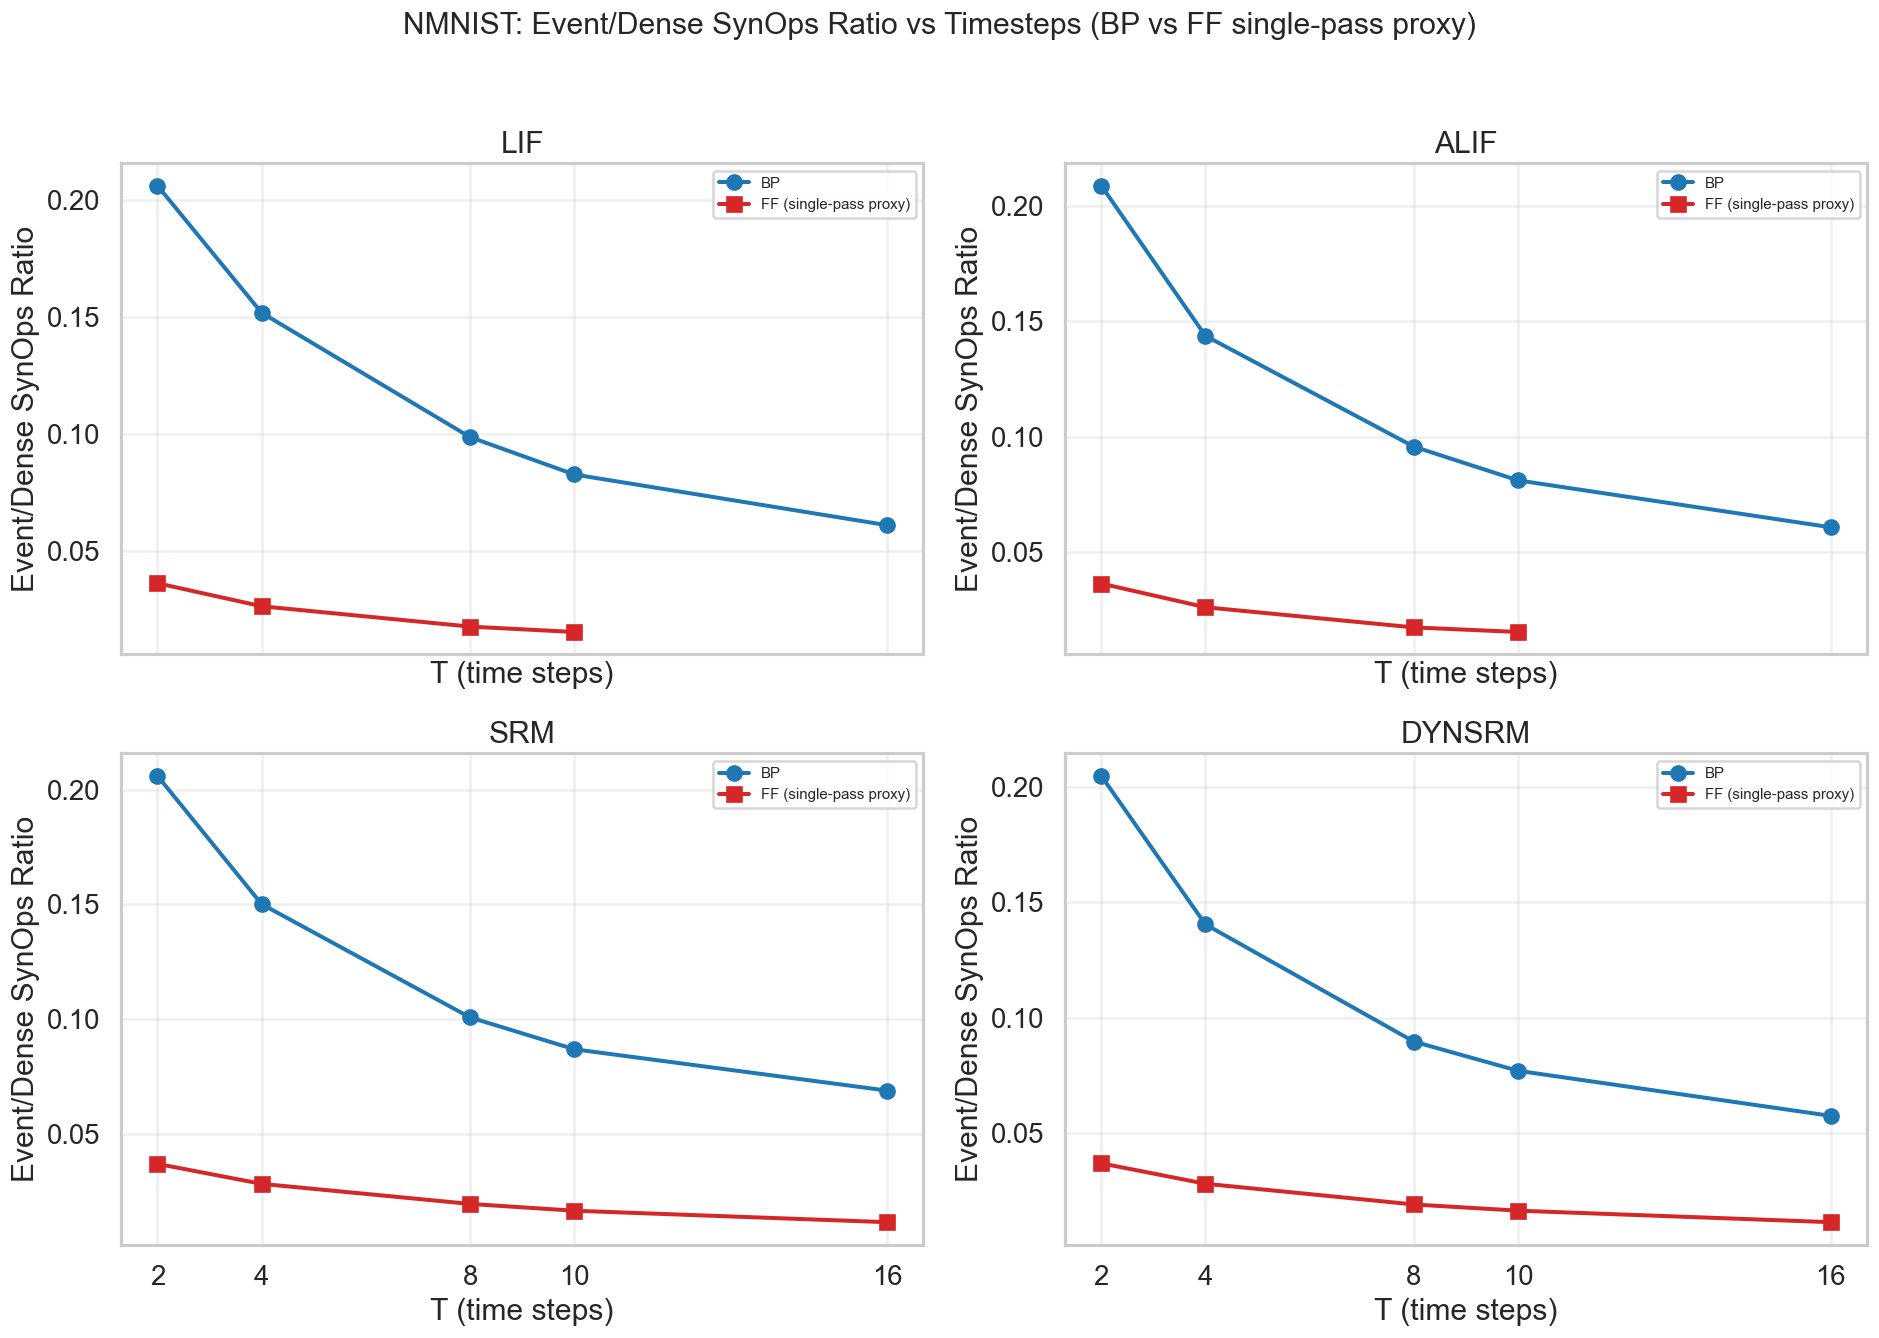

Saved table: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/NMNIST/v2/result/timestep/plots/bp_ff_event_dense_ratio_vs_timestep_nmnist_single_pass_proxy_table.csv


In [15]:
# Replot with single-pass FF ratio proxy
# Assumption: FF candidate-based ratio is scaled by number of label candidates.
# For NMNIST (10 classes), use FF_single_pass_proxy = FF_ratio / 10.

if "ratio_df" not in globals() or ratio_df.empty:
    raise RuntimeError("Please run the Event/Dense ratio cell first to create ratio_df.")

NUM_CLASSES = 10
ratio_single_df = ratio_df.copy()
ratio_single_df["event_dense_ratio_single_pass"] = ratio_single_df["event_dense_ratio"]

ff_mask = ratio_single_df["method"] == "FF"
ratio_single_df.loc[ff_mask, "event_dense_ratio_single_pass"] = (
    ratio_single_df.loc[ff_mask, "event_dense_ratio_single_pass"] / NUM_CLASSES
)

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True, sharey=False)
axes = axes.ravel()

for i, model in enumerate(NEURONS):
    ax = axes[i]
    sub = ratio_single_df[ratio_single_df["model"] == model]

    bp = sub[sub["method"] == "BP"].sort_values("T")
    ff_raw = sub[sub["method"] == "FF"].sort_values("T")

    ax.plot(bp["T"], bp["event_dense_ratio"], marker="o", linewidth=2.4,
            color="#1f77b4", label="BP")
    ax.plot(ff_raw["T"], ff_raw["event_dense_ratio_single_pass"], marker="s", linewidth=2.4,
            color="#d62728", label="FF (single-pass proxy)")
    #ax.plot(ff_raw["T"], ff_raw["event_dense_ratio"], marker="s", linestyle="--", linewidth=1.4,
            #alpha=0.65, color="#ff7f0e", label="FF raw (candidate-based)")

    ax.set_title(model.upper())
    ax.set_xlabel("T (time steps)")
    ax.set_ylabel("Event/Dense SynOps Ratio")
    ax.set_xticks(TS)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=9)

fig.suptitle("NMNIST: Event/Dense SynOps Ratio vs Timesteps (BP vs FF single-pass proxy)", fontsize=18, y=1.02)
fig.tight_layout()

ratio_single_fig_path = OUT_DIR / "bp_ff_event_dense_ratio_vs_timestep_nmnist_single_pass_proxy.png"
fig.savefig(ratio_single_fig_path, bbox_inches="tight")
print(f"Saved figure: {ratio_single_fig_path}")
plt.show()

ratio_single_table_path = OUT_DIR / "bp_ff_event_dense_ratio_vs_timestep_nmnist_single_pass_proxy_table.csv"
ratio_single_df.to_csv(ratio_single_table_path, index=False)
print(f"Saved table: {ratio_single_table_path}")

Memory rows: 40


,method,model,T,gpu_alloc_mb,gpu_reserved_mb,cpu_mb,csv_path,exists
0,BP,alif,2,48.233398,72.0,1821.660156,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
1,BP,alif,4,51.144043,76.0,1815.921875,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
2,BP,alif,8,64.365234,86.0,2002.710938,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
3,BP,alif,10,71.348145,112.0,1890.316406,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
4,BP,alif,16,93.995117,126.0,2094.792969,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
5,FF,alif,2,700.033203,1012.0,1995.933594,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
6,FF,alif,4,1347.035156,2006.0,3402.085938,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
7,FF,alif,8,2627.851562,3290.0,5152.710938,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
8,FF,alif,10,3270.220703,4776.0,5488.347656,/home/yhxu/spikingjelly/spikingjelly/spikingje...,True
9,FF,alif,16,NaN,NaN,NaN,/home/yhxu/spikingjelly/spikingjelly/spikingje...,False


,method,model,T,batch_size,effective_sample_factor,effective_batch_size,gpu_reserved_mb,gpu_reserved_mb_per_sample,gpu_reserved_mb_eq_target_batch
0,BP,alif,2,128.0,1.0,128.0,72.0,0.562500,72.00000
1,BP,alif,4,128.0,1.0,128.0,76.0,0.593750,76.00000
2,BP,alif,8,128.0,1.0,128.0,86.0,0.671875,86.00000
3,BP,alif,10,128.0,1.0,128.0,112.0,0.875000,112.00000
4,BP,alif,16,128.0,1.0,128.0,126.0,0.984375,126.00000
5,FF,alif,2,4096.0,2.0,8192.0,1012.0,0.123535,15.81250
6,FF,alif,4,4096.0,2.0,8192.0,2006.0,0.244873,31.34375
7,FF,alif,8,4096.0,2.0,8192.0,3290.0,0.401611,51.40625
8,FF,alif,10,4096.0,2.0,8192.0,4776.0,0.583008,74.62500
9,FF,alif,16,4096.0,2.0,8192.0,NaN,NaN,NaN


Saved figure: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/NMNIST/v2/result/timestep/plots/bp_ff_memory_vs_timestep_nmnist_fair_batch_normalized.png


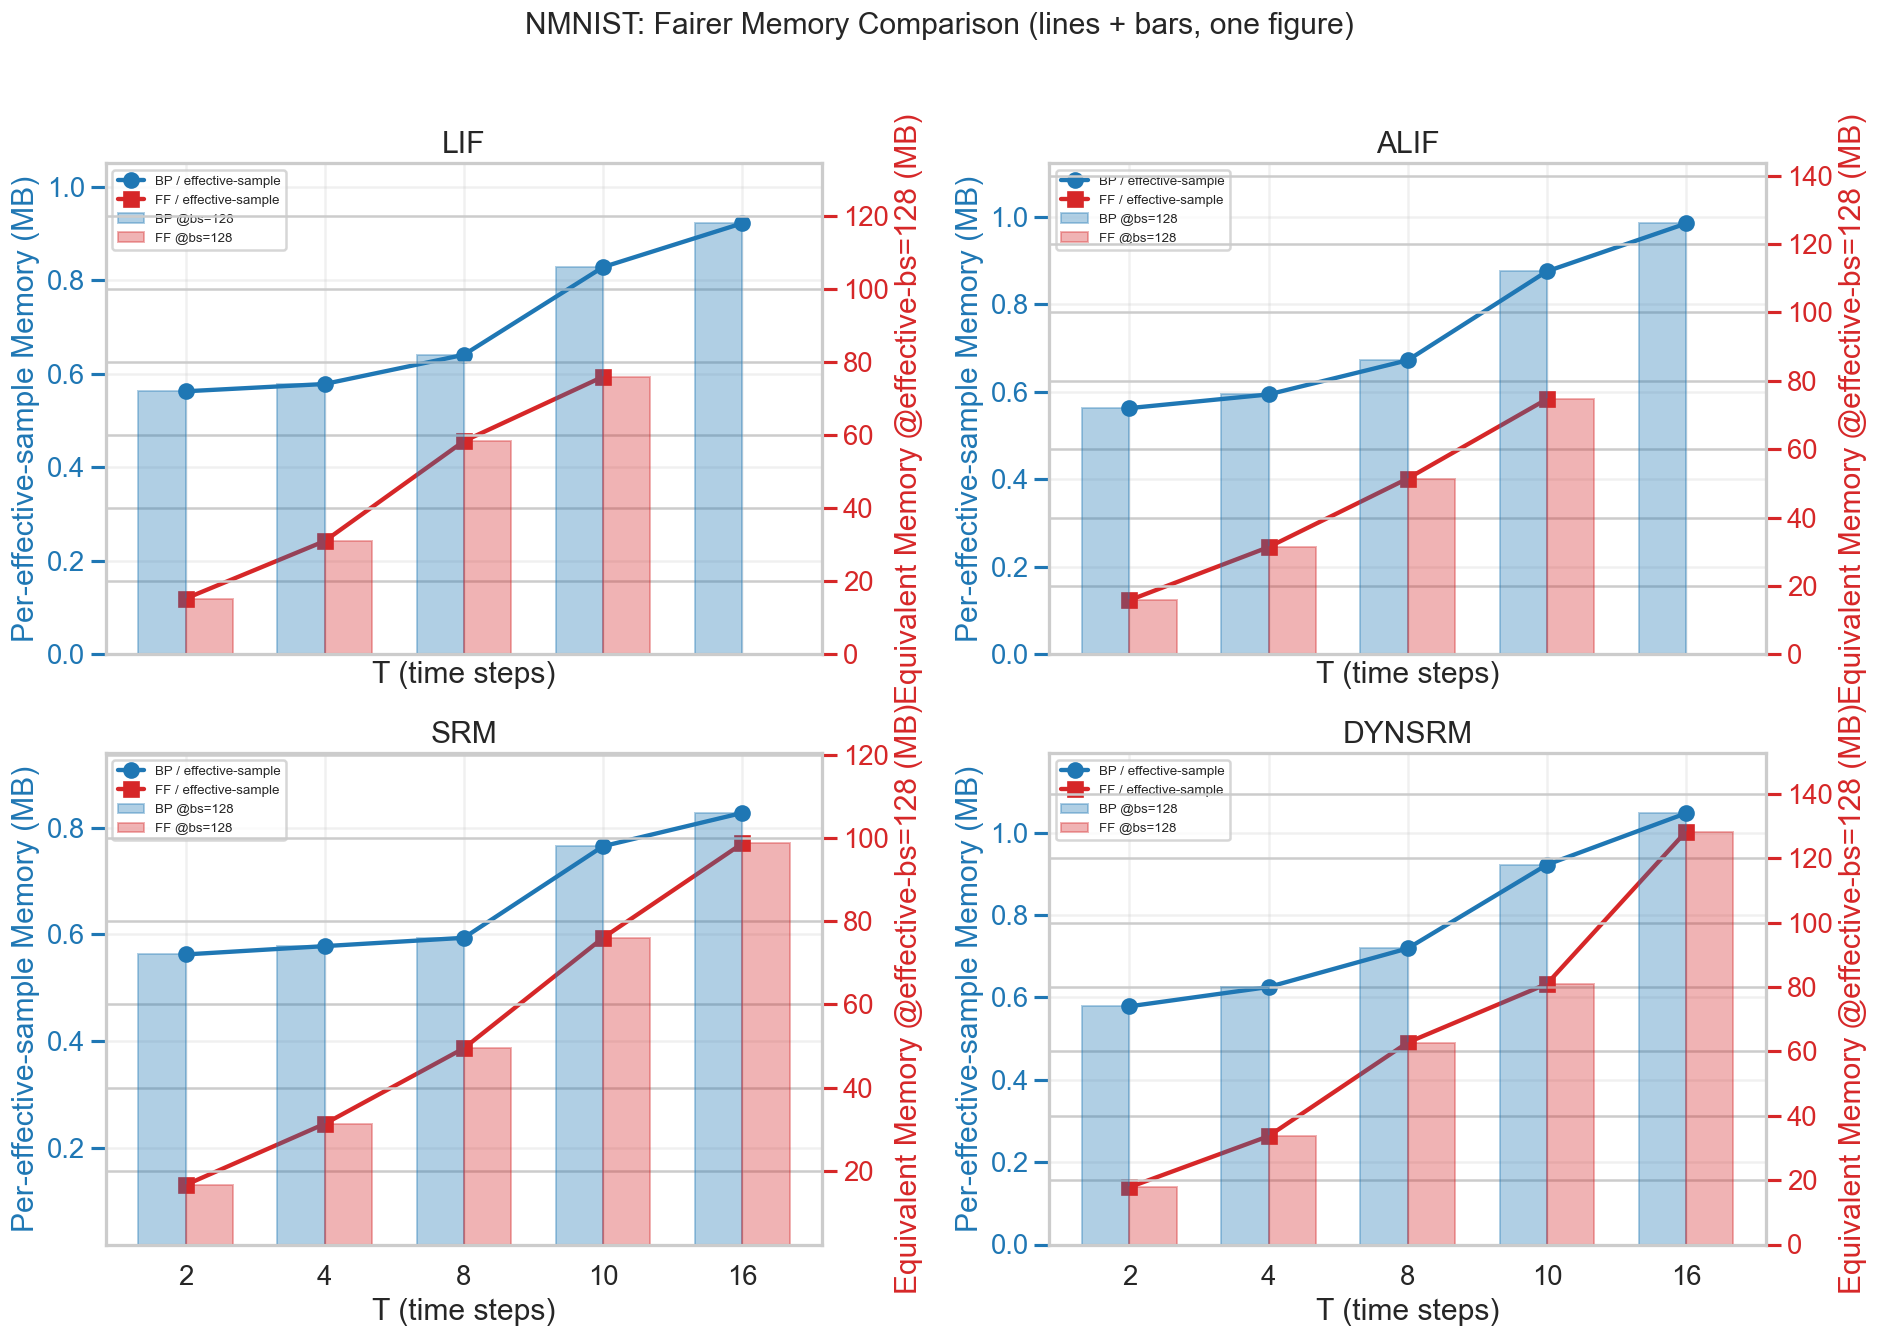

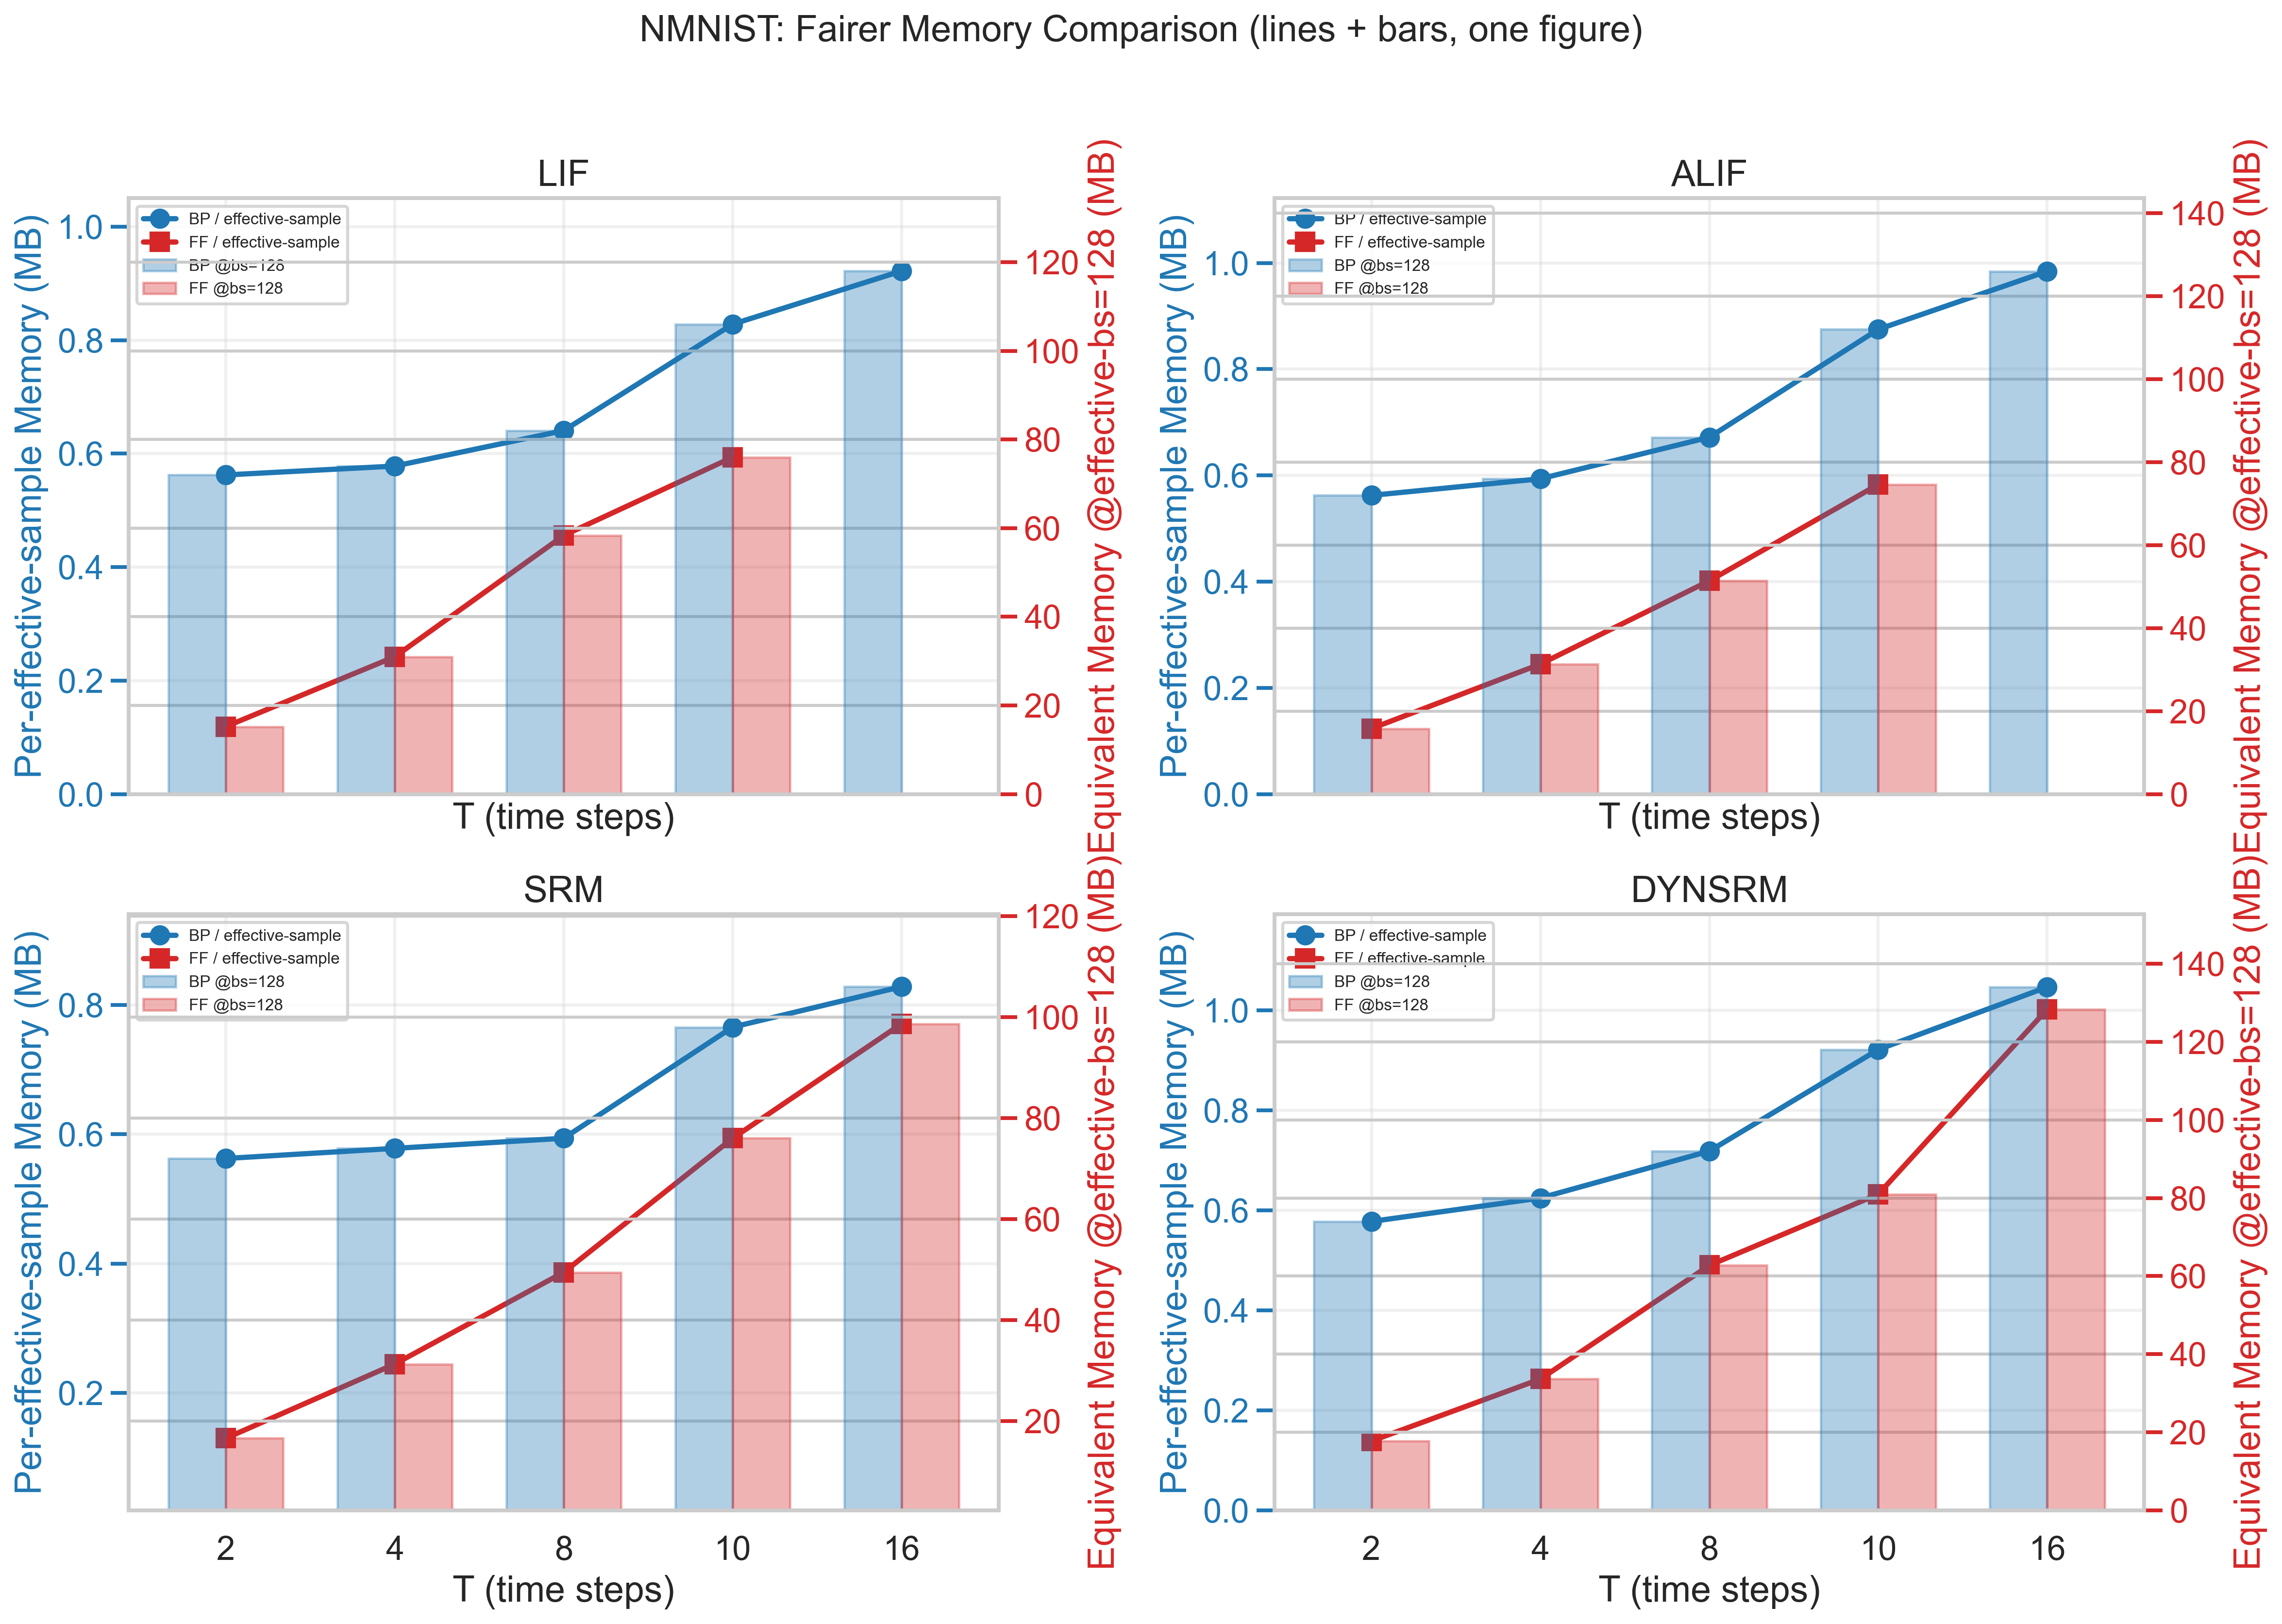

Saved table: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/NMNIST/v2/result/timestep/plots/bp_ff_memory_vs_timestep_nmnist_fair_batch_normalized_table.csv


In [7]:
# Fairer memory comparison under different batch sizes (BP=128, FF=4096) for NMNIST
# 1) memory per sample
# 2) memory scaled to an equivalent target batch size (default 128)


def read_memory_from_csv(csv_path: Path):
    try:
        df = pd.read_csv(csv_path)
    except Exception:
        return {"gpu_alloc_mb": np.nan, "gpu_reserved_mb": np.nan, "cpu_mb": np.nan}

    if df.empty:
        return {"gpu_alloc_mb": np.nan, "gpu_reserved_mb": np.nan, "cpu_mb": np.nan}

    score_col = "best_test_acc" if "best_test_acc" in df.columns else ("test_acc" if "test_acc" in df.columns else None)
    if score_col is None:
        row = df.iloc[-1]
    else:
        score = pd.to_numeric(df[score_col], errors="coerce")
        row = df.iloc[int(score.fillna(-np.inf).idxmax())]

    def _num(name):
        if name not in df.columns:
            return np.nan
        return float(pd.to_numeric(pd.Series([row[name]]), errors="coerce").iloc[0])

    train_gpu_alloc = _num("train_gpu_memory_allocated_mb")
    test_gpu_alloc = _num("test_gpu_memory_allocated_mb")
    train_gpu_reserved = _num("train_gpu_memory_reserved_mb")
    test_gpu_reserved = _num("test_gpu_memory_reserved_mb")
    train_cpu = _num("train_cpu_memory_mb")
    test_cpu = _num("test_cpu_memory_mb")

    return {
        "gpu_alloc_mb": np.nanmax([train_gpu_alloc, test_gpu_alloc]),
        "gpu_reserved_mb": np.nanmax([train_gpu_reserved, test_gpu_reserved]),
        "cpu_mb": np.nanmax([train_cpu, test_cpu]),
    }


mem_records = []
for model in NEURONS:
    for t in TS:
        for method in ["BP", "FF"]:
            csv_path = method_csv_path(method, model, t)
            mem = read_memory_from_csv(csv_path)
            mem_records.append({
                "method": method,
                "model": model,
                "T": t,
                "gpu_alloc_mb": mem["gpu_alloc_mb"],
                "gpu_reserved_mb": mem["gpu_reserved_mb"],
                "cpu_mb": mem["cpu_mb"],
                "csv_path": str(csv_path),
                "exists": csv_path.exists(),
            })

mem_df = pd.DataFrame(mem_records).sort_values(["model", "method", "T"]).reset_index(drop=True)
print("Memory rows:", len(mem_df))
display(mem_df)

BATCH_SIZE_BY_METHOD = {"BP": 128.0, "FF": 4096.0}
# FF local learning usually processes positive+negative branches together,
# so use 2x effective samples for per-sample normalization.
EFFECTIVE_SAMPLE_FACTOR = {"BP": 1.0, "FF": 2.0}
TARGET_BATCH = 128.0

fair_df = mem_df.copy()
fair_df["batch_size"] = fair_df["method"].map(BATCH_SIZE_BY_METHOD)
fair_df["effective_sample_factor"] = fair_df["method"].map(EFFECTIVE_SAMPLE_FACTOR)
fair_df["effective_batch_size"] = fair_df["batch_size"] * fair_df["effective_sample_factor"]

# Normalize by effective sample count.
fair_df["gpu_reserved_mb_per_sample"] = fair_df["gpu_reserved_mb"] / fair_df["effective_batch_size"]
fair_df["gpu_alloc_mb_per_sample"] = fair_df["gpu_alloc_mb"] / fair_df["effective_batch_size"]

# Scale to equivalent target batch (approximate linear scaling assumption).
scale = TARGET_BATCH / fair_df["effective_batch_size"]
fair_df["gpu_reserved_mb_eq_target_batch"] = fair_df["gpu_reserved_mb"] * scale
fair_df["gpu_alloc_mb_eq_target_batch"] = fair_df["gpu_alloc_mb"] * scale

display(
    fair_df[
        [
            "method", "model", "T", "batch_size", "effective_sample_factor", "effective_batch_size", "gpu_reserved_mb",
            "gpu_reserved_mb_per_sample", "gpu_reserved_mb_eq_target_batch",
        ]
    ]
)

from IPython.display import display, Image

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True)
axes = axes.ravel()

bp_color = "#1f77b4"  # blue
ff_color = "#d62728"  # red

for i, model in enumerate(NEURONS):
    ax_l = axes[i]
    ax_r = ax_l.twinx()

    sub = fair_df[fair_df["model"] == model]
    bp = sub[sub["method"] == "BP"].sort_values("T")
    ff = sub[sub["method"] == "FF"].sort_values("T")

    x = np.arange(len(TS))
    width = 0.34

    # Right axis: equivalent memory at target batch (bars)
    bp_eq = bp["gpu_reserved_mb_eq_target_batch"].values
    ff_eq = ff["gpu_reserved_mb_eq_target_batch"].values
    b1 = ax_r.bar(
        x - width / 2, bp_eq, width=width, color=bp_color, alpha=0.35,
        edgecolor=bp_color, linewidth=1.2, label=f"BP @bs={int(TARGET_BATCH)}"
    )
    b2 = ax_r.bar(
        x + width / 2, ff_eq, width=width, color=ff_color, alpha=0.35,
        edgecolor=ff_color, linewidth=1.2, label=f"FF @bs={int(TARGET_BATCH)}"
    )

    # Left axis: per-sample memory (lines)
    l1, = ax_l.plot(
        x, bp["gpu_reserved_mb_per_sample"].values, marker="o", linewidth=2.6,
        color=bp_color, label="BP / effective-sample"
    )
    l2, = ax_l.plot(
        x, ff["gpu_reserved_mb_per_sample"].values, marker="s", linewidth=2.6,
        color=ff_color, label="FF / effective-sample"
    )

    left_vals = np.concatenate([
        bp["gpu_reserved_mb_per_sample"].dropna().values,
        ff["gpu_reserved_mb_per_sample"].dropna().values,
    ])
    if left_vals.size > 0:
        lmin, lmax = np.nanmin(left_vals), np.nanmax(left_vals)
        pad = max((lmax - lmin) * 0.16, 1e-6)
        ax_l.set_ylim(max(0.0, lmin - pad), lmax + pad)

    right_vals = np.concatenate([
        bp["gpu_reserved_mb_eq_target_batch"].dropna().values,
        ff["gpu_reserved_mb_eq_target_batch"].dropna().values,
    ])
    if right_vals.size > 0:
        rmin, rmax = np.nanmin(right_vals), np.nanmax(right_vals)
        pad = max((rmax - rmin) * 0.16, 1e-6)
        ax_r.set_ylim(max(0.0, rmin - pad), rmax + pad)

    ax_l.set_title(model.upper())
    ax_l.set_xlabel("T (time steps)")
    ax_l.set_xticks(x)
    ax_l.set_xticklabels(TS)
    ax_l.set_ylabel("Per-effective-sample Memory (MB)", color=bp_color)
    ax_r.set_ylabel(f"Equivalent Memory @effective-bs={int(TARGET_BATCH)} (MB)", color=ff_color)
    ax_l.tick_params(axis="y", colors=bp_color)
    ax_r.tick_params(axis="y", colors=ff_color)
    ax_l.grid(True, alpha=0.28)

    handles = [l1, l2, b1, b2]
    labels = [h.get_label() for h in handles]
    ax_l.legend(handles, labels, fontsize=8, loc="best")

fig.suptitle("NMNIST: Fairer Memory Comparison (lines + bars, one figure)", fontsize=18, y=1.02)
fig.tight_layout()

fair_fig_path = OUT_DIR / "bp_ff_memory_vs_timestep_nmnist_fair_batch_normalized.png"
fig.savefig(fair_fig_path, bbox_inches="tight")
print(f"Saved figure: {fair_fig_path}")
plt.show()

# Explicit inline display in notebook
try:
    display(Image(filename=str(fair_fig_path)))
except Exception:
    pass

fair_table_path = OUT_DIR / "bp_ff_memory_vs_timestep_nmnist_fair_batch_normalized_table.csv"
fair_df.to_csv(fair_table_path, index=False)
print(f"Saved table: {fair_table_path}")